In [1]:
!pip install transformers --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: smokenandos
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection


100%|██████████| 3.30M/3.30M [00:00<00:00, 195MB/s]

In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = 'cuda' if torch.cuda.is_available() else "cpu"

print("Available Device: ", device)

Available Device:  cuda


In [3]:
data_df = pd.read_json('/content/news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json', lines = True)
data_df.dropna(inplace = True)
data_df.drop_duplicates(inplace = True)
data_df.drop(['article_link'], inplace = True, axis = 1)

print(data_df.shape)
data_df.head()

(26708, 2)


,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(np.array(data_df["headline"]), np.array(data_df["is_sarcastic"]), test_size = 0.5)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size = 0.4)

print("Training Size: ", X_train.shape[0], " rows which is: ", round(X_train.shape[0]/data_df.shape[0], 4) * 100, "%")
print("Validation Size: ", X_val.shape[0], " rows which is: ", round(X_val.shape[0]/data_df.shape[0], 4) * 100, "%")
print("Training Size: ", X_test.shape[0], " rows which is: ", round(X_test.shape[0]/data_df.shape[0], 4) * 100, "%")

Training Size:  13354  rows which is:  50.0 %
Validation Size:  8012  rows which is:  30.0 %
Training Size:  5342  rows which is:  20.0 %


In [5]:
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
bert_model = AutoModel.from_pretrained("google-bert/bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [31]:
class dataset(Dataset):
  def __init__(self, X, Y):
    self.X = [tokenizer(x,
              max_length = 120,
              truncation = True,
              padding = "max_length",
              return_tensors = 'pt').to(device)
              for x in X
    ]
    self.Y = torch.tensor(Y, dtype = torch.float32).to(device)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, indx):
    return self.X[indx], self.Y[indx]

training_data = dataset(X_train, y_train)
validation_data = dataset(X_val, y_val)
testing_data = dataset(X_test, y_test)



In [32]:
BATCH_SIZE = 40
EPOCHS = 20
LR = 1e-4

In [33]:
train_dataloader = DataLoader(training_data, batch_size = BATCH_SIZE, shuffle = True)
validation_dataloader = DataLoader(validation_data, batch_size = BATCH_SIZE, shuffle = True)
testing_dataloader = DataLoader(testing_data, batch_size = BATCH_SIZE, shuffle = True)


In [34]:
class MyModel(nn.Module):
  def __init__(self, bert):
    super(MyModel, self).__init__()

    self.bert = bert
    self.dropout = nn.Dropout(0.6)
    self.linear1 = nn.Linear(768, 384)
    self.linear2 = nn.Linear(384, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, input_ids, attention_mask):
    pooled_output = self.bert(input_ids, attention_mask, return_dict = False)[0][:, 0]
    output = self.linear1(pooled_output)
    output = self.dropout(output)
    output = self.linear2(output)
    output = self.sigmoid(output)
    return output


In [35]:
for param in bert_model.parameters():
  param.requires_grad = False

model = MyModel(bert_model).to(device)

In [36]:
model

MyModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=Tr

In [37]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr = LR)

In [42]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_acc_val = 0
  total_loss_val = 0

  for indx, data in enumerate(train_dataloader):
    inputs, labels = data
    inputs.to(device)
    labels.to(device)

    prediction = model(inputs["input_ids"].squeeze(1), inputs["attention_mask"].squeeze(1)).squeeze(1)
    batch_loss = criterion(prediction, labels)
    total_loss_train += batch_loss.item()

    acc = (prediction.round() == labels).sum().item()

    total_acc_train += acc

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for indx, data in enumerate(validation_dataloader):
      inputs, labels = data
      inputs.to(device)
      labels.to(device)

      prediction = model(inputs["input_ids"].squeeze(1), inputs["attention_mask"].squeeze(1)).squeeze(1)
      batch_loss = criterion(prediction, labels)
      total_loss_val += batch_loss.item()

      acc = (prediction.round() == labels).sum().item()

      total_acc_val += acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/training_data.__len__() * 100, 4))
  total_acc_validation_plot.append(round(total_acc_val/validation_data.__len__() * 100, 4))

  print(f"""
  Epoch No. {epoch+1} Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy: {round(total_acc_train/training_data.__len__() * 100, 4)}
                      Validation Loss: {round(total_loss_val/1000, 4)} Validation Accuracy {round(total_acc_val/validation_data.__len__() * 100, 4)}
  """)






  Epoch No. 1 Train Loss: 0.1336 Train Accuracy: 83.0912
                      Validation Loss: 0.0773 Validation Accuracy 83.7119
  
  

  Epoch No. 2 Train Loss: 0.124 Train Accuracy: 84.2594
                      Validation Loss: 0.0736 Validation Accuracy 84.3485
  
  

  Epoch No. 3 Train Loss: 0.1183 Train Accuracy: 85.0082
                      Validation Loss: 0.0719 Validation Accuracy 84.0864
  
  

  Epoch No. 4 Train Loss: 0.1143 Train Accuracy: 85.4426
                      Validation Loss: 0.0708 Validation Accuracy 84.4109
  
  

  Epoch No. 5 Train Loss: 0.1112 Train Accuracy: 85.9068
                      Validation Loss: 0.0689 Validation Accuracy 84.985
  
  

  Epoch No. 6 Train Loss: 0.1095 Train Accuracy: 85.9143
                      Validation Loss: 0.0689 Validation Accuracy 84.8228
  
  

  Epoch No. 7 Train Loss: 0.1076 Train Accuracy: 86.0416
                      Validation Loss: 0.0681 Validation Accuracy 85.3095
  
  

  Epoch No. 8 Train Loss: 0.1073 Tr

KeyboardInterrupt: 

In [43]:
model.to(device)

MyModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=Tr

In [44]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for indx, data in enumerate(testing_dataloader):
    inputs, labels = data
    inputs.to(device)
    labels.to(device)

    prediction = model(inputs["input_ids"].squeeze(1), inputs["attention_mask"].squeeze(1)).squeeze(1)
    batch_loss = criterion(prediction, labels)
    total_loss_test += batch_loss.item()

    acc = (prediction.round() == labels).sum().item()

    total_acc_test += acc

print(f"Accuracy Score on Testing Data: {round(total_acc_test/testing_data.__len__() * 100, 4)}")

Accuracy Score on Testing Data: 85.8854


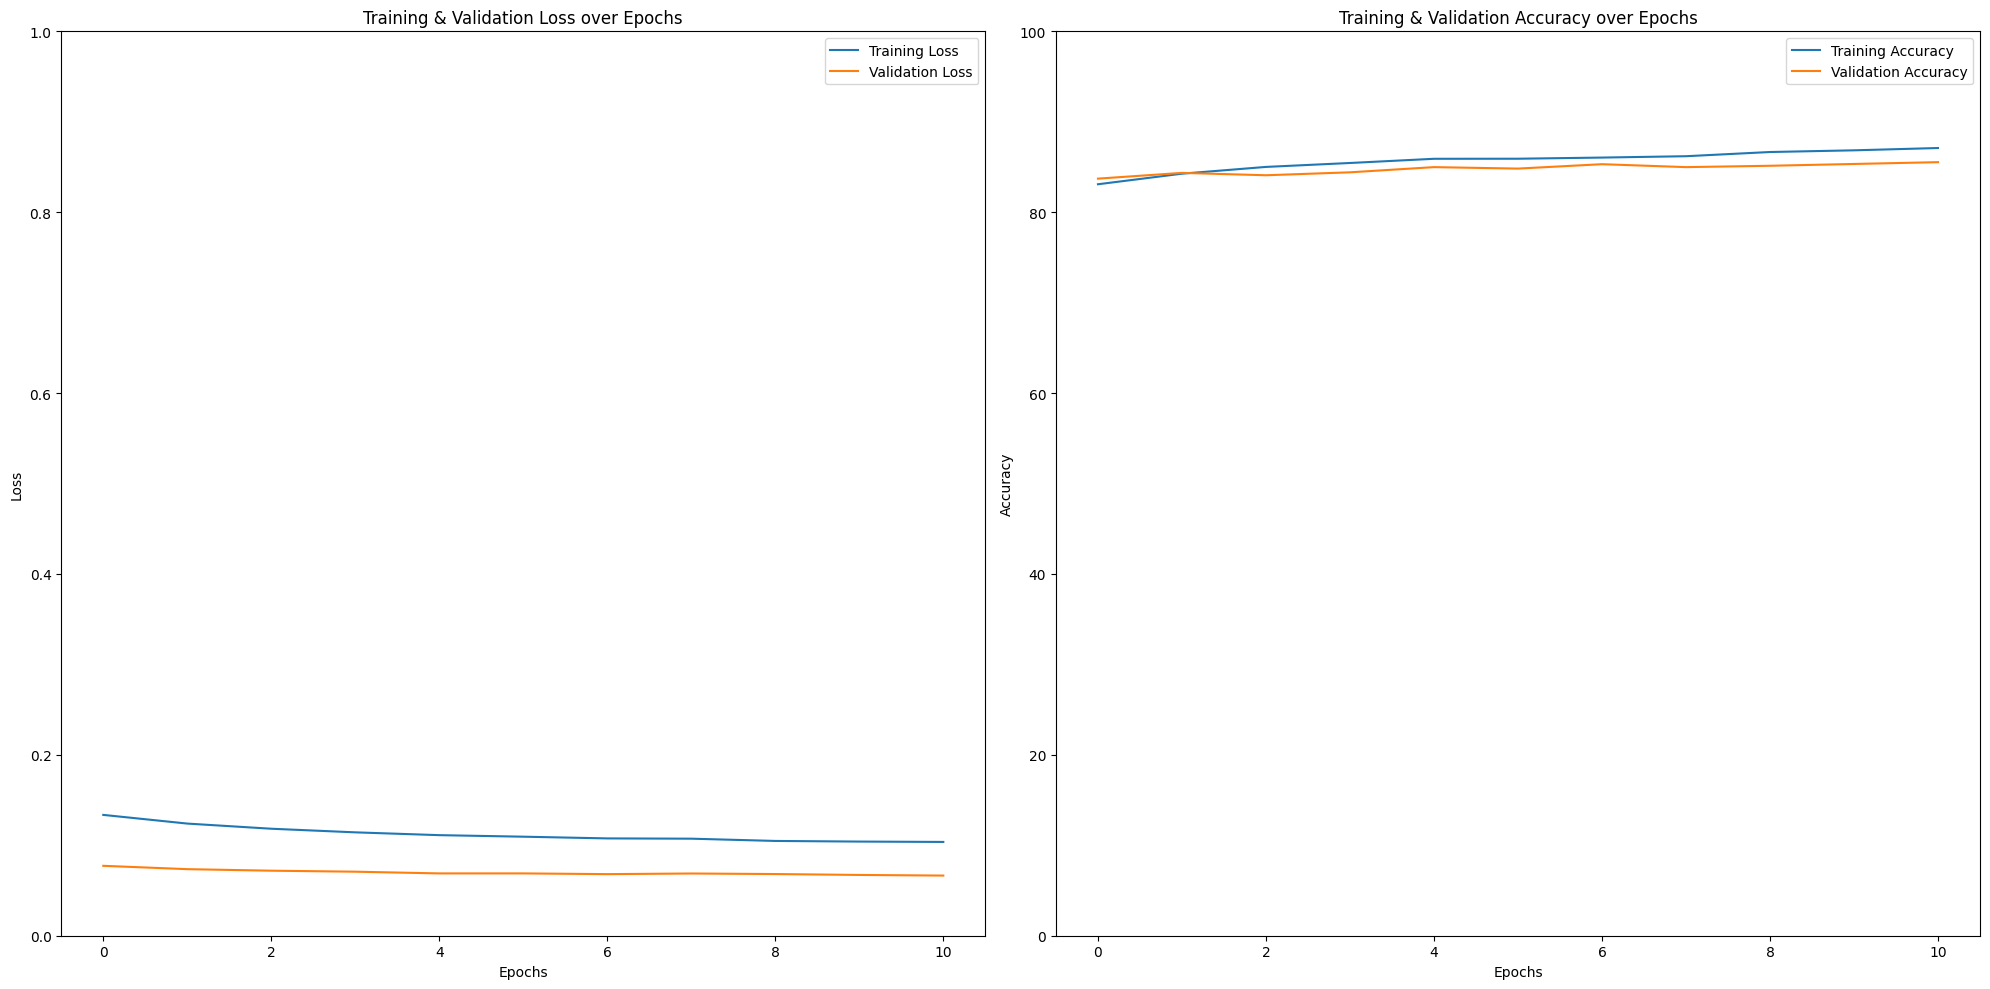

In [49]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (20, 10))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training & Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel("Loss")
axs[0].set_ylim([0, 1])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training & Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel("Accuracy")
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()
plt.show()